# Kidney Stone QSVM Benchmark
QSVM classification experiment using CVAT-annotated kidney stone endoscopy frames (COCO instance segmentation).

**Pipeline**

294 frames -> present(250)/absent(44) labels -> balanced sampling
  -> ResNet-18(frozen) 512-dim feature extraction -> StandardScaler -> PCA(n_qubits)
  -> MinMaxScaler([-pi,pi]) -> video_block_split -> ZZFeatureMap quantum kernel -> SVC

  
Note: Since the 44 "absent" frames are temporally clustered within the video (e.g., frames 071-077 occur consecutively), a random split would cause leakage. This is mitigated using video_block_split.

In [1]:
# Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from data_loader import load_labels_from_coco, load_kidney_stone_dataset, video_block_split, _frame_number
from models import run_qsvm

np.random.seed(42)


## 1. Verify Annotations (COCO Label Distribution)

present (stone visible): 250
absent  (no annotation): 44


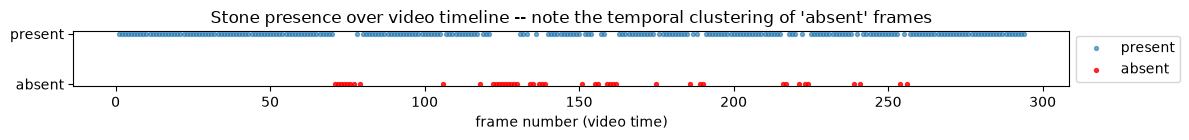

In [2]:
# Load present/absent labels directly from the COCO annotation file
labels = load_labels_from_coco("instances_default.json")

n_present = sum(v == 1 for v in labels.values())
n_absent  = sum(v == 0 for v in labels.values())
print(f"present (stone visible): {n_present}")
print(f"absent  (no annotation): {n_absent}")

# Visualize that "absent" frames are temporally clustered, not randomly scattered
absent_frame_nums = sorted(_frame_number(f) for f, y in labels.items() if y == 0)
present_frame_nums = sorted(_frame_number(f) for f, y in labels.items() if y == 1)

plt.figure(figsize=(12, 1.5))
plt.scatter(present_frame_nums, [1]*len(present_frame_nums), s=8, label="present", alpha=0.6)
plt.scatter(absent_frame_nums, [0]*len(absent_frame_nums), s=8, color="red", label="absent", alpha=0.8)
plt.yticks([0, 1], ["absent", "present"])
plt.xlabel("frame number (video time)")
plt.title("Stone presence over video timeline -- note the temporal clustering of 'absent' frames")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()


## 2. Data Loading + Feature Extraction
This downloads ImageNet-pretrained ResNet-18 weights on first run (requires network access).

Set max_samples to around 60–100, given that QSVM scales as O(N^2).


In [3]:
# n_qubits = PCA output dimension; max_samples = total balanced sample count (QSVM is O(N^2))
N_QUBITS = 4
MAX_SAMPLES = 80

# Full pipeline: COCO labels -> balanced sample -> ResNet-18 features -> StandardScaler -> PCA -> [-pi, pi] scaling
X, y, files, raw_512 = load_kidney_stone_dataset(
    coco_json_path="instances_default.json",
    image_dir="images/kidney_stone/kidney video.jpg",
    n_qubits=N_QUBITS,
    max_samples=MAX_SAMPLES,
    seed=42,
)

print("X_quantum shape:", X.shape)
print("class balance:", np.bincount(y))


[data] Selected 80 samples -> present=40, absent=40
  [feature extraction] 16/80
  [feature extraction] 32/80
  [feature extraction] 48/80
  [feature extraction] 64/80
  [feature extraction] 80/80
[data] PCA explained variance ratio (n_qubits=4): 0.460
X_quantum shape: (80, 4)
class balance: [40 40]


### After PCA (plot features into 2D map)

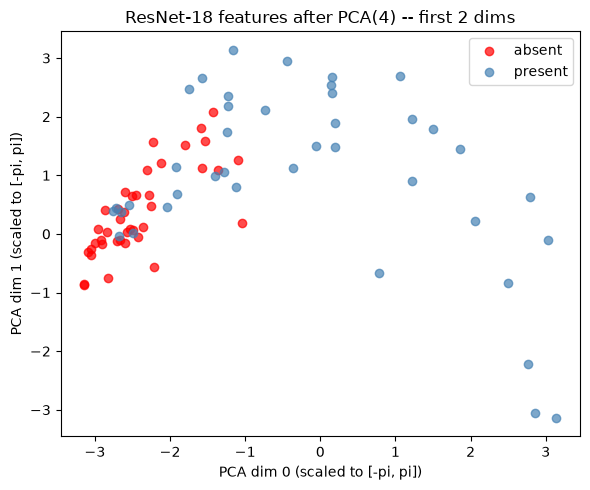

In [5]:
# Scatter plot of the first two PCA dimensions, colored by class
plt.figure(figsize=(6, 5))
for label, name, color in [(0, "absent", "red"), (1, "present", "steelblue")]:
    mask = y == label
    plt.scatter(X[mask, 0], X[mask, 1], label=name, alpha=0.7, color=color)
plt.xlabel("PCA dim 0 (scaled to [-pi, pi])")
plt.ylabel("PCA dim 1 (scaled to [-pi, pi])")
plt.title("ResNet-18 features after PCA(4) -- first 2 dims")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Train / Test split（video-block, leakage）

In [6]:
# Video-block split avoids leaking near-duplicate adjacent frames across train/test
train_idx, test_idx = video_block_split(files, y, test_size=0.25, gap=5, seed=42)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"train: {len(train_idx)}  (balance: {np.bincount(y_train)})")
print(f"test:  {len(test_idx)}  (balance: {np.bincount(y_test)})")

test_frames = sorted(_frame_number(files[i]) for i in test_idx)
print("test frame numbers:", test_frames)


train: 50  (balance: [21 29])
test:  20  (balance: [10 10])
test frame numbers: [79, 81, 87, 88, 94, 98, 104, 106, 108, 113, 114, 115, 118, 122, 123, 125, 126, 127, 128, 129]


## 4. QSVM

`backend="aer"` AerSimulator + finite shots（more realistic)

`backend="statevector"` precise but not realistic


In [7]:
# Train and evaluate QSVM (quantum kernel via ZZFeatureMap + classical SVC)
result = run_qsvm(
    X_train, y_train, X_test, y_test,
    n_qubits=N_QUBITS, reps=2,
    backend="aer", shots=1024,
    seed=42, C=1.0,
)


[QSVM] Building quantum kernel (n_qubits=4, reps=2, backend=aer)
[QSVM] Computing training kernel matrix (50x50)... this is O(N^2) quantum circuit evaluations, may take a while.
[QSVM] Computing test kernel matrix (20x50)...
[QSVM] train_kernel_time=4.3s  test_kernel_time=2.9s  svc_fit_time=0.01s
[QSVM] Accuracy=0.650  F1=0.720  AUC=0.360
[QSVM] Confusion matrix:
[[4 6]
 [1 9]]


/opt/anaconda3/envs/qml_endo/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Visualize the confusion matrix

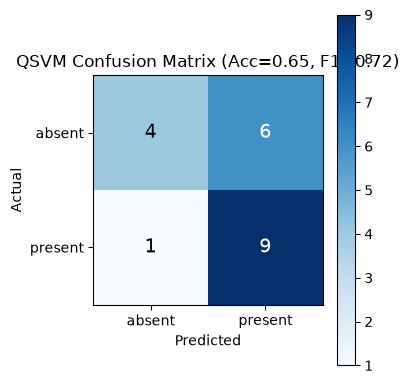

In [8]:
# Plot the confusion matrix for the QSVM result
cm = result["confusion_matrix"]
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                  color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.xticks([0, 1], ["absent", "present"])
plt.yticks([0, 1], ["absent", "present"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"QSVM Confusion Matrix (Acc={result['accuracy']:.2f}, F1={result['f1']:.2f})")
plt.colorbar()
plt.tight_layout()
plt.show()


## 5. Comparison: How Much Does Accuracy Get "Inflated" with a Random Split?
This quantifies the impact of temporal leakage by comparing against video_block_split.


In [9]:
# Compare against a plain random stratified split to quantify the leakage effect
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

result_random = run_qsvm(
    X_train_r, y_train_r, X_test_r, y_test_r,
    n_qubits=N_QUBITS, reps=2,
    backend="aer", shots=1024,
    seed=42, C=1.0,
)

comparison = pd.DataFrame([
    {"split": "video_block (recommended)", "Accuracy": result["accuracy"], "F1": result["f1"], "AUC": result["auc"]},
    {"split": "random (leakage risk)",     "Accuracy": result_random["accuracy"], "F1": result_random["f1"], "AUC": result_random["auc"]},
])
comparison


[QSVM] Building quantum kernel (n_qubits=4, reps=2, backend=aer)
[QSVM] Computing training kernel matrix (60x60)... this is O(N^2) quantum circuit evaluations, may take a while.
[QSVM] Computing test kernel matrix (20x60)...
[QSVM] train_kernel_time=6.7s  test_kernel_time=4.1s  svc_fit_time=0.00s
[QSVM] Accuracy=0.700  F1=0.727  AUC=0.230
[QSVM] Confusion matrix:
[[6 4]
 [2 8]]


/opt/anaconda3/envs/qml_endo/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,split,Accuracy,F1,AUC
0,video_block (recommended),0.65,0.720000,0.36
1,random (leakage risk),0.70,0.727273,0.23


## 6. Result

In [10]:
# Save final metrics summary to CSV
import os
os.makedirs("results", exist_ok=True)

summary = pd.DataFrame([
    {"Model": "QSVM", "split": "video_block", "Accuracy": result["accuracy"],
     "F1": result["f1"], "AUC": result["auc"], "n_qubits": N_QUBITS, "max_samples": MAX_SAMPLES},
    {"Model": "QSVM", "split": "random", "Accuracy": result_random["accuracy"],
     "F1": result_random["f1"], "AUC": result_random["auc"], "n_qubits": N_QUBITS, "max_samples": MAX_SAMPLES},
])
summary.to_csv("results/qsvm_metrics_notebook.csv", index=False)
summary


,Model,split,Accuracy,F1,AUC,n_qubits,max_samples
0,QSVM,video_block,0.65,0.720000,0.36,4,80
1,QSVM,random,0.70,0.727273,0.23,4,80
